Prob of Claim (1m data): 25.2%
Prob of Claim (100m data): 2.2%
Prob of Claim (100m data): 0.0%


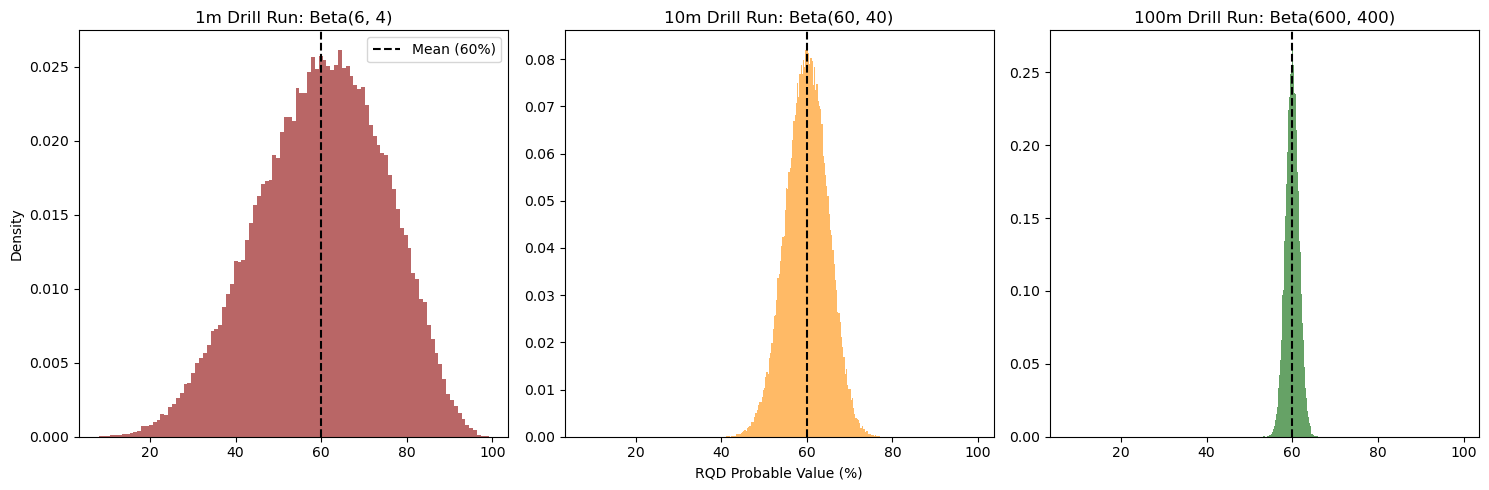

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate Bianshi (Variation) vectors for evidence masses
n_sim = 100000

# OVERRIDE: Yes, you can scale Beta from (0-1) to (0-100) by simply multiplying by 100.
# np.random.beta ALWAYS outputs between 0.0 and 1.0.
# Multiplying by 100 converts the probability into a percentage (e.g., for RQD or RMR).
rqd_1m = np.random.beta(a=6, b=4, size=n_sim) * 100       # High Risk / Ignorance
rqd_10m = np.random.beta(a=60, b=40, size=n_sim) * 100    # Moderate Risk
rqd_100m = np.random.beta(a=600, b=400, size=n_sim) * 100 # Contractual Certainty

prob_claim_1m = (rqd_1m < 50).mean()
prob_claim_10m = (rqd_10m < 50).mean()
prob_claim_100m = (rqd_100m < 50).mean()

print(f"Prob of Claim (1m data): {prob_claim_1m * 100:.1f}%")
print(f"Prob of Claim (100m data): {prob_claim_10m * 100:.1f}%")
print(f"Prob of Claim (100m data): {prob_claim_100m * 100:.1f}%")

# Visualization Architecture
# We share the X-axis so you can physically see the extreme tails closing in.

# plt.hist(rqd_low, bins=50, density=True, alpha=0.5, label="1m Drill Run")

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

# Subplot 1: 1m Drill
axs[0].hist(rqd_1m, bins='fd', density=True, alpha=0.6, color='darkred')
axs[0].axvline(60, color='k', linestyle='dashed', label="Mean (60%)")
axs[0].set_title("1m Drill Run: Beta(6, 4)")
axs[0].set_ylabel("Density")
axs[0].legend()

# Subplot 2: 10m Drill
axs[1].hist(rqd_10m, bins='fd', density=True, alpha=0.6, color='darkorange')
axs[1].axvline(60, color='k', linestyle='dashed')
axs[1].set_title("10m Drill Run: Beta(60, 40)")
axs[1].set_xlabel("RQD Probable Value (%)")

# Subplot 3: 100m Drill
axs[2].hist(rqd_100m, bins='fd', density=True, alpha=0.6, color='darkgreen')
axs[2].axvline(60, color='k', linestyle='dashed')
axs[2].set_title("100m Drill Run: Beta(600, 400)")

plt.tight_layout()
plt.show()

# mean is the same however the distribution is different tottally
# claim as per fidic 4.12

Scenario 1 (Collapse Focus)
Average Expected Collapse Rate: 5.00%
FIDIC 4.12 Baseline (p95): Contractor must account for up to 14.58% collapse rate without claims.


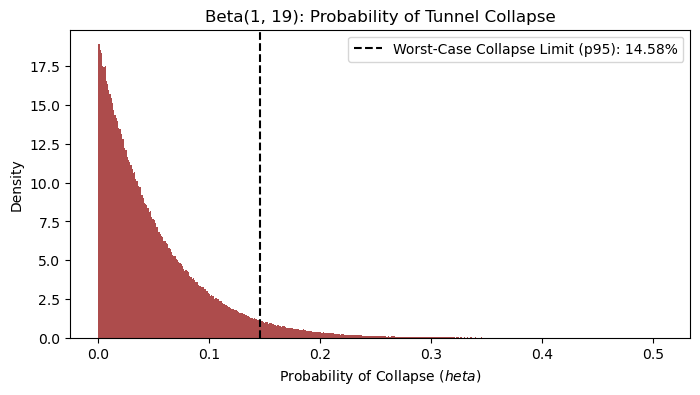

In [29]:

# Scientific Intent: Modeling the Probability of Encountering Bad Rock (Collapse Event)
n_simulations = 1000000
tunn_fail = np.random.beta(a=1, b=19, size=n_simulations)

# The Commercial Shield (95th Percentile)
# Physical meaning: We are 95% confident the TRUE collapse rate will not safely exceed this value.
p95_collapse = np.percentile(tunn_fail, 95)

print("Scenario 1 (Collapse Focus)")
print(f"Average Expected Collapse Rate: {np.mean(tunn_fail):.2%}")
print(f"FIDIC 4.12 Baseline (p95): Contractor must account for up to {p95_collapse:.2%} collapse rate without claims.")

plt.figure(figsize=(8, 4))
plt.hist(tunn_fail, bins='fd', density=True, color='darkred', alpha=0.7)
plt.axvline(p95_collapse, color='black', linestyle='dashed', #type:ignore
            label=f"Worst-Case Collapse Limit (p95): {p95_collapse:.2%}")
plt.title("Beta(1, 19): Probability of Tunnel Collapse")
plt.xlabel("Probability of Collapse ($\theta$)")
plt.ylabel("Density")
plt.legend()
plt.show()

Scenario 2 (Survival Focus)
Average Expected Survival Rate: 95.01%
Operational Minimum (p5): In the worst-case scenario, only 85.41% of the rock will remain intact.


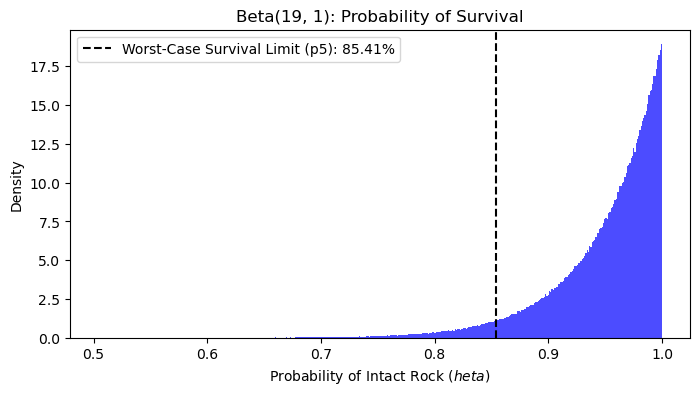

In [30]:
# Scientific Intent: Modeling the Probability of Encountering Intact Rock (Survival Event)
tunn_survive = np.random.beta(a=19, b=1, size=n_simulations)

# The Survival Blind Spot (5th Percentile)
# Physical meaning: We are 95% confident the TRUE survival rate will not drop below this value.
p5_survival = np.percentile(tunn_survive, 5)

print("Scenario 2 (Survival Focus)")
print(f"Average Expected Survival Rate: {np.mean(tunn_survive):.2%}")
print(f"Operational Minimum (p5): In the worst-case scenario, only {p5_survival:.2%} of the rock will remain intact.")

plt.figure(figsize=(8, 4))
plt.hist(tunn_survive, bins='fd', density=True, color='blue', alpha=0.7)
plt.axvline(p5_survival, color='black', linestyle='dashed', #type:ignore
            label=f"Worst-Case Survival Limit (p5): {p5_survival:.2%}")
plt.title("Beta(19, 1): Probability of Survival")
plt.xlabel("Probability of Intact Rock ($\theta$)")
plt.ylabel("Density")
plt.legend()
plt.show()

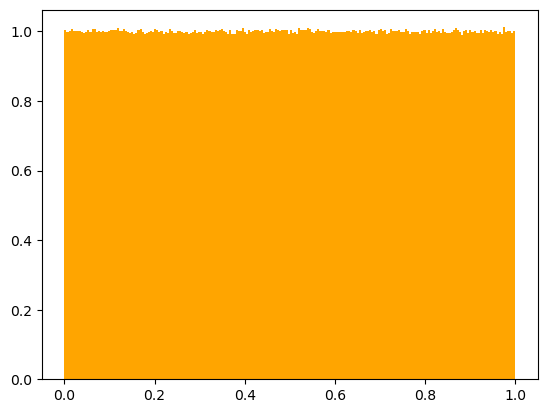

In [ ]:
np.random.seed(42)
uni = np.random.beta(1,1, 10000000)

plt.hist(uni, bins='fd', density=True, color="orange")
plt.show()

# equal probability for anything from 1 to 100